# 4. 

Llamamos 𝜃 a la proporción de vampiros que les gusta bailar tango. Supongamos que el prior
para 𝜃 es una distribución beta con media 0.6 y varianza 0.015.
- (a) Determinar los hiperparámetros 𝛼 y 𝛽 del prior y graficar la prior.
    

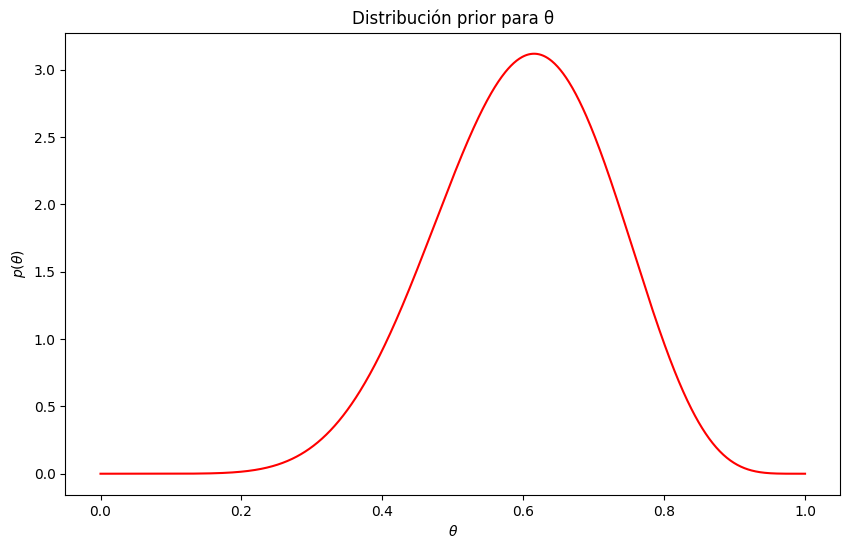

In [1]:
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt 

grilla_theta = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 6))
plt.plot(grilla_theta, beta.pdf(grilla_theta,9,6), color="red")
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta)$')
plt.title("Distribución prior para θ")
plt.show()

- (b) Se lleva a cabo una encuesta a 1000 vampiros y se obtiene que al 65% le gusta bailar tango.
¿Cuál es la media y el desvío estándar para 𝜃? Graficar la distribución posterior.



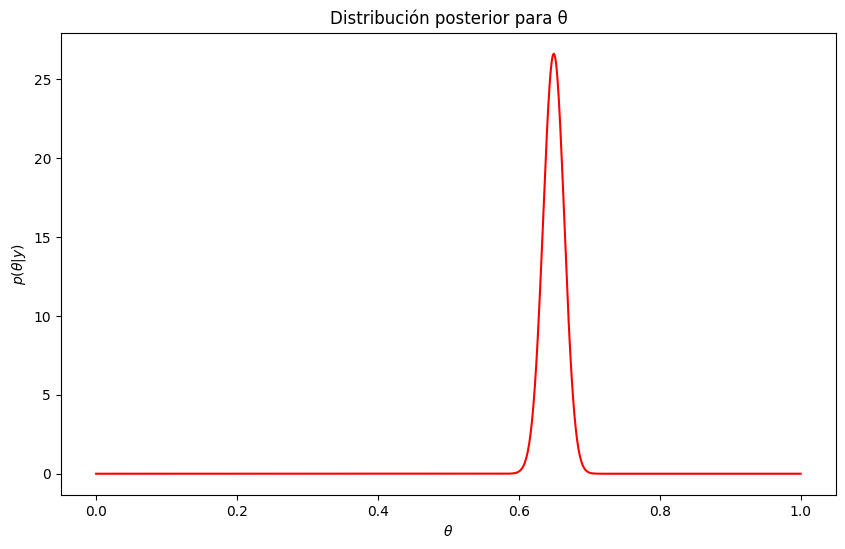

In [2]:
y = 650
n = 1000

plt.figure(figsize=(10, 6))
plt.plot(grilla_theta, beta.pdf(grilla_theta,9 + y, 6 + n - y), color="red")
plt.xlabel(r'$\theta$')
plt.ylabel(r'$p(\theta|y)$')
plt.title("Distribución posterior para θ")
plt.show()

In [3]:
esperanza_posterior = (9 + y) / (9 + y + 6 + n - y)
desvio_estandar_posterior = np.sqrt((9 + y)*(6 + n - y) / ((9 + y + 6 + n - y)**2 * (9 + y + 6 + n - y + 1)))

print(f'La media de la distribución posterior es: {esperanza_posterior}')
print(f'La desviación estándar de la distribución posterior es: {desvio_estandar_posterior}')

La media de la distribución posterior es: 0.6492610837438424
La desviación estándar de la distribución posterior es: 0.014971137878254227


- (c) Evaluar la sensibilidad de la distribución posterior respecto de distintas medias y varianzas
previas, incluyendo un prior uniforme.

In [ ]:
# se arma una funcion para ver esa comparativa
def comparacion_priors(priors, y, n):
    x = np.linspace(0, 1, 1000)
    plt.figure(figsize=(10, 6))

    for prior in priors:
        a, b = prior
        posterior = beta(a+y, b+n-y)
        plt.plot(x, posterior.pdf(x), label=f'Prior Beta({a}, {b})',alpha=0.8)

    plt.xlabel(r'$\theta$')
    plt.ylabel(r'$p(\theta|y)$')
    plt.title('Comparación de Distribuciones Posteriores para distintos priors')
    plt.legend()
    plt.show()


priors = [(1,1),(3,2),(9,6),(90,60),(900,600),(9000,6000)]
comparacion_priors(priors, y, n)


- (d) Volviendo al prior original y los datos obtenidos ¿cuál es la probabilidad de que al próximo
vampiro encuestado le guste bailar el tango?